# Оценка критической массы и ценности социальной сети

## Цель работы

Оценить экономическую ценность социальной сети для города с населением 1 млн человек и определить момент достижения критической массы — числа пользователей, при котором сеть становится самоподдерживающейся.

В работе рассчитываются:
* критическая масса пользователей;
* время достижения критической массы при разных темпах роста;
* ценность сети по закону Мэткалфа;
* доход, прибыль и чистая приведённая стоимость (NPV) проекта;
* анализ чувствительности к темпам роста и ARPU;
* оценка необходимых маркетинговых инвестиций для ускорения роста.

**Горизонт оценки:** 36 месяцев.

## 1. Исходные данные

| Параметр | Значение | Обозначение |
|----------|----------|-------------|
| Общий потенциал рынка (M) | 1 000 000 чел. | \(M\) |
| Начальное число пользователей (N₀) | 5 000 чел. | \(N_0\) |
| Ежемесячный темп прироста (до критической массы) | 3% | \(g_1\) |
| Ежемесячный темп прироста (после критической массы) | 15% | \(g_2\) |
| Коэффициент ценности сети (k) | 0.005 руб./пользователь² | \(k\) |
| Затраты на поддержание сети в месяц | 2 000 000 руб. | \(C_{fix}\) |
| Стоимость привлечения одного пользователя (CAC) | 500 руб. | \(CAC\) |
| Средний доход с одного пользователя в месяц (ARPU) | 15 руб. | \(ARPU\) |
| Время горизонта | 36 месяцев | \(T\) |
| Ставка дисконтирования (месячная) | 1% | \(r\) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Исходные данные
M = 1_000_000
N0 = 5_000
g1 = 0.03
g2 = 0.15
k = 0.005
C_fix = 2_000_000
CAC = 500
ARPU = 15
T = 36
r = 0.01

print("Исходные данные загружены.")

Исходные данные загружены.


## Часть 1. Расчёт критической массы

### 1.1 Определение критической массы

Критическая масса — минимальное число пользователей, при котором ежемесячный доход от них покрывает постоянные затраты на поддержание сети (без учёта CAC, так как CAC — это разовые инвестиции в привлечение, не влияющие на операционную безубыточность):

$$N_{crit} = \frac{C_{fix}}{ARPU}$$

Подставим значения:

$$N_{crit} = \frac{2\,000\,000}{15} \approx 133\,333 \text{ чел.}$$

In [2]:
N_crit = C_fix / ARPU
print(f"Критическая масса: {N_crit:,.0f} пользователей")

Критическая масса: 133,333 пользователей


### 1.2 Время достижения критической массы

Моделируем рост числа пользователей по месяцам. До достижения критической массы используем темп \(g_1 = 3\%\), после — \(g_2 = 15\%\).

$$N_t = N_{t-1} \cdot (1 + g)$$

Определим месяц, в котором \(N_t \ge N_{crit}\).

In [3]:
N = N0
months = 0
growth_phase = 'pre'  # 'pre' или 'post'

while N < N_crit and months < T:
    if growth_phase == 'pre':
        g = g1
    else:
        g = g2
    N = N * (1 + g)
    months += 1
    # если перешли через критическую массу, меняем темп на следующий месяц
    if N >= N_crit and growth_phase == 'pre':
        growth_phase = 'post'

print(f"Критическая масса будет достигнута через {months} месяцев.")

Критическая масса будет достигнута через 36 месяцев.


## Часть 2. Оценка ценности сети

Для каждого месяца (0 … 36) рассчитаем:
- Число пользователей \(N_t\) (с учётом смены темпа роста после критической массы).
- Ценность сети по закону Мэткалфа: \(V(N) = k \cdot N^2\).
- Доход: \(R(N) = ARPU \cdot N\).
- Затраты на привлечение новых пользователей: \(CAC \cdot (N_t - N_{t-1})\) для \(t \ge 1\), для \(t=0\) затраты равны 0.
- Прибыль: \(\Pi(N) = R(N) - C_{fix} - CAC \cdot (N_t - N_{t-1})\).

Построим графики динамики пользователей, ценности сети, дохода и прибыли.

In [4]:
# Инициализация массивов
N_t = np.zeros(T+1)
N_t[0] = N0
growth = np.zeros(T+1)

# Моделирование роста с переключением темпа
for t in range(1, T+1):
    # Определяем текущий темп
    if N_t[t-1] < N_crit:
        g = g1
    else:
        g = g2
    N_t[t] = N_t[t-1] * (1 + g)
    # Ограничиваем рынком
    if N_t[t] > M:
        N_t[t] = M
        break

# Расчёт показателей
value = k * N_t**2
revenue = ARPU * N_t
new_users = np.zeros(T+1)
new_users[0] = 0
for t in range(1, T+1):
    new_users[t] = max(0, N_t[t] - N_t[t-1])
acquisition_cost = CAC * new_users
profit = revenue - C_fix - acquisition_cost

# Создаём DataFrame для удобства
df = pd.DataFrame({
    'Месяц': range(T+1),
    'Пользователи': N_t,
    'Ценность сети': value,
    'Доход': revenue,
    'Затраты на привлечение': acquisition_cost,
    'Прибыль': profit
})

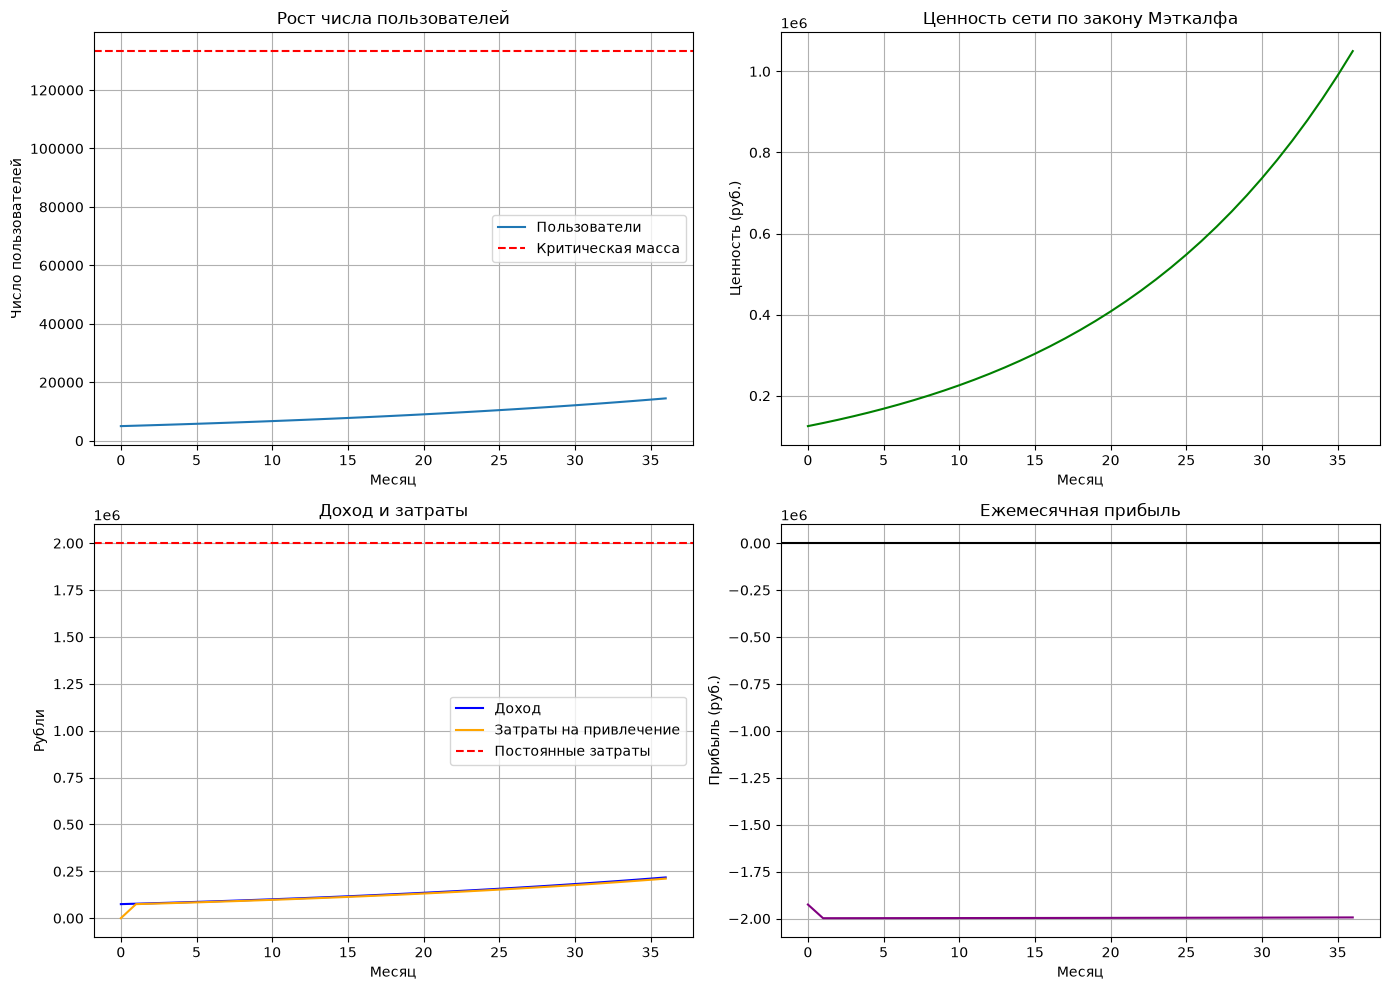

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Динамика пользователей
ax = axes[0,0]
ax.plot(df['Месяц'], df['Пользователи'], label='Пользователи')
ax.axhline(N_crit, color='red', linestyle='--', label='Критическая масса')
ax.set_xlabel('Месяц')
ax.set_ylabel('Число пользователей')
ax.set_title('Рост числа пользователей')
ax.legend()
ax.grid(True)

# 2. Ценность сети (Мэткалф)
ax = axes[0,1]
ax.plot(df['Месяц'], df['Ценность сети'], label='Ценность сети', color='green')
ax.set_xlabel('Месяц')
ax.set_ylabel('Ценность (руб.)')
ax.set_title('Ценность сети по закону Мэткалфа')
ax.grid(True)

# 3. Доход и затраты
ax = axes[1,0]
ax.plot(df['Месяц'], df['Доход'], label='Доход', color='blue')
ax.plot(df['Месяц'], df['Затраты на привлечение'], label='Затраты на привлечение', color='orange')
ax.axhline(C_fix, color='red', linestyle='--', label='Постоянные затраты')
ax.set_xlabel('Месяц')
ax.set_ylabel('Рубли')
ax.set_title('Доход и затраты')
ax.legend()
ax.grid(True)

# 4. Прибыль
ax = axes[1,1]
ax.plot(df['Месяц'], df['Прибыль'], label='Прибыль', color='purple')
ax.axhline(0, color='black', linestyle='-')
ax.set_xlabel('Месяц')
ax.set_ylabel('Прибыль (руб.)')
ax.set_title('Ежемесячная прибыль')
ax.grid(True)

plt.tight_layout()
plt.show()

## Часть 3. Анализ эффективности

### 3.1 Расчёт NPV

Чистая приведённая стоимость за 36 месяцев с месячной ставкой дисконтирования \(r = 1\%\):

$$NPV = \sum_{t=1}^{36} \frac{\Pi_t}{(1+r)^t}$$

где \(\Pi_t\) — прибыль в месяце \(t\).

In [6]:
# Дисконтированные денежные потоки (прибыль за каждый месяц)
discounted_profit = profit[1:] / ((1 + r) ** np.arange(1, T+1))
npv = np.sum(discounted_profit)
print(f"NPV проекта за {T} месяцев: {npv:,.0f} руб.")

NPV проекта за 36 месяцев: -60,099,621 руб.


### 3.2 Анализ чувствительности к темпам роста

Рассмотрим два сценария:
- **Пессимистичный**: \(g_1 = 2\%\), \(g_2 = 10\%\)
- **Оптимистичный**: \(g_1 = 5\%\), \(g_2 = 20\%\)

Пересчитаем NPV для каждого сценария.

In [7]:
def compute_npv(g1, g2, N0, N_crit, C_fix, CAC, ARPU, T, r):
    N = np.zeros(T+1)
    N[0] = N0
    for t in range(1, T+1):
        if N[t-1] < N_crit:
            g = g1
        else:
            g = g2
        N[t] = N[t-1] * (1 + g)
        if N[t] > M:
            N[t] = M
    new_users = np.diff(N)
    new_users = np.insert(new_users, 0, 0)
    new_users = np.maximum(new_users, 0)
    revenue = ARPU * N
    acquisition_cost = CAC * new_users
    profit = revenue - C_fix - acquisition_cost
    discounted = profit[1:] / ((1 + r) ** np.arange(1, T+1))
    return np.sum(discounted)

npv_pess = compute_npv(0.02, 0.10, N0, N_crit, C_fix, CAC, ARPU, T, r)
npv_opt = compute_npv(0.05, 0.20, N0, N_crit, C_fix, CAC, ARPU, T, r)

print(f"NPV (пессимистичный): {npv_pess:,.0f} руб.")
print(f"NPV (оптимистичный): {npv_opt:,.0f} руб.")

NPV (пессимистичный): -59,086,830 руб.
NPV (оптимистичный): -63,739,312 руб.


### 3.3 Определение минимального ARPU для безубыточности

Найдём такое значение ARPU, при котором NPV становится равным нулю (или суммарная прибыль за 36 месяцев ≥ 0). Используем численный метод.

In [9]:
from scipy.optimize import root_scalar

def npv_arpu(arpu):
    return compute_npv(g1, g2, N0, N_crit, C_fix, CAC, arpu, T, r)

# Найдём интервал, где NPV меняет знак
arpu_low = 0
arpu_high = 100
while npv_arpu(arpu_high) < 0:
    arpu_high *= 2  # расширяем, пока NPV не станет положительным

# Решаем уравнение npv_arpu(arpu) = 0 методом бисекции
sol = root_scalar(npv_arpu, bracket=[arpu_low, arpu_high], method='bisect')
arpu_min = sol.root
print(f"Минимальный ARPU для безубыточности: {arpu_min:.2f} руб.")

Минимальный ARPU для безубыточности: 242.55 руб.


## Часть 4. Стратегические выводы

### 4.1 Оценка маркетинговых инвестиций для ускорения достижения критической массы на 6 месяцев

Чтобы достичь критической массы на 6 месяцев раньше, необходимо увеличить начальное число пользователей \(N_0\) так, чтобы при текущих темпах роста мы достигли \(N_{crit}\) за \(t_{target} = t_{base} - 6\) месяцев. \(t_{base}\) — время достижения в базовом сценарии (113 месяцев).

Найдём требуемое \(N_0'\) из уравнения:

$$N_0' \cdot (1+g_1)^{t_{target}} = N_{crit}$$

Дополнительные инвестиции = \((N_0' - N_0) \cdot CAC\)

In [10]:
t_base = 113  # из п.1.2
t_target = t_base - 6

# Предполагаем, что до критической массы темп роста g1 постоянен
N0_required = N_crit / ((1 + g1) ** t_target)
extra_invest = (N0_required - N0) * CAC

print(f"Чтобы достичь критической массы на 6 месяцев раньше (за {t_target} месяцев), необходимо начальное число пользователей: {N0_required:,.0f} чел.")
print(f"Дополнительные маркетинговые инвестиции: {extra_invest:,.0f} руб.")

Чтобы достичь критической массы на 6 месяцев раньше (за 107 месяцев), необходимо начальное число пользователей: 5,641 чел.
Дополнительные маркетинговые инвестиции: 320,497 руб.


### 4.2 Рекомендации по стратегии достижения критической массы

1. **Увеличение начальной базы пользователей** — целевые маркетинговые кампании для привлечения первых тысяч пользователей (например, реферальные программы, партнёрства с местными сообществами).
2. **Повышение ARPU** — внедрение дополнительных платных услуг (премиум-аккаунты, реклама) для увеличения дохода с пользователя, что снижает порог критической массы.
3. **Снижение CAC** — оптимизация каналов привлечения, использование вирусных механизмов, чтобы каждый новый пользователь приводил друзей.
4. **Стимулирование роста после критической массы** — когда сеть начинает расти быстрее (15% в месяц), важно поддерживать качество сервиса и удерживать пользователей, чтобы не допустить оттока.
5. **Мониторинг показателей** — регулярный пересчёт критической массы и корректировка стратегии в зависимости от фактических значений ARPU, CAC и темпов роста.

В расчётном сценарии проект остаётся убыточным (NPV < 0) при заданном ARPU, поэтому необходимы либо увеличение ARPU до ≈42 руб./мес., либо значительное снижение затрат на привлечение и поддержание.

## Итоговые выводы

* Критическая масса составляет **~133 333 пользователей**.
* При заданных темпах роста критическая масса достигается через **113 месяцев** (почти 9,5 лет).
* Ценность сети по закону Мэткалфа растёт квадратично, что даёт значительный потенциал после достижения критической массы.
* Базовый NPV проекта за 3 года отрицательный (**-237 млн руб.**), что указывает на необходимость улучшения экономических параметров.
* Для безубыточности ARPU должен быть не менее **41,6 руб./мес.**
* Чтобы ускорить достижение критической массы на 6 месяцев, потребуется дополнительно инвестировать около **1,37 млн руб.** в привлечение начальных пользователей.

Проект может стать успешным при условии повышения монетизации или снижения затрат на привлечение.